# Milestone 3 — Stage 1: source ray sampling and face coverage

Evidence notebook for **M3 Stage 1**: `SourceRayBundle` generation, `first_visible_hits` on source rays, and non-refracted `accumulate_source_coverage`.

Plan: [`plans/milestone_03/03_face_transport_plan.md`](../../plans/milestone_03/03_face_transport_plan.md). Read next: `03_1_snell_helper_testing.ipynb` → `03_2_refraction.ipynb`.

## Checks

1. Directional source grid targets the mesh bbox.
2. Source-ray invariants (unit directions, non-negative weights).
3. Entry-face hits and `FaceOpticalState` coverage.
4. Sample face energy / coverage / incident `b_out` through the **camera** `hit_faces` bridge.


In [1]:
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

!pip install --quiet --no-cache-dir "{ROOT}[dev]" -c "{ROOT}/requirements.txt"

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [2]:
from gummybear.geometry import inspect_stl
from gummybear.optics import (
    DirectionalLightConfig,
    SourceSamplingParams,
    accumulate_source_coverage,
    make_source_ray_bundle,
)
from gummybear.rays.camera import PinholeCameraConfig, make_pinhole_rays
from gummybear.rays.visibility import first_visible_hits
from gummybear_validation.helpers import (
    assert_source_hit_contract,
    assert_source_ray_bundle_invariants,
    print_face_state_summary,
    print_source_hit_summary,
)
from gummybear_validation.plotting import (
    plot_face_state_camera_panel,
    plot_face_state_on_mesh_3d,
    plot_source_rays_with_bbox,
    sample_face_state_camera_images,
)


In [3]:
inspection = inspect_stl(ROOT / "cad" / "proto_bear.stl")
mesh = inspection["mesh"]
print(f"vertices={len(mesh.vertices)}  faces={len(mesh.faces)}")
print("bounds:", mesh.bounds)


vertices=9083  faces=18162
bounds: [[-14.46015263  -9.66969395  -5.        ]
 [ 12.22403431  10.57715702  10.        ]]


In [4]:
light = DirectionalLightConfig(propagation_direction=(0.0, 1.0, -1.0), intensity=1.0)
# Match upstream Stage 1 evidence: dense direction grid (512×512 parallel rays).
sampling = SourceSamplingParams(direction_n_samples=512)

source_rays = make_source_ray_bundle(
    light=light,
    mesh_bbox=mesh.bounds,
    sampling=sampling,
)
print(source_rays.n_rays, "source rays")


262144 source rays


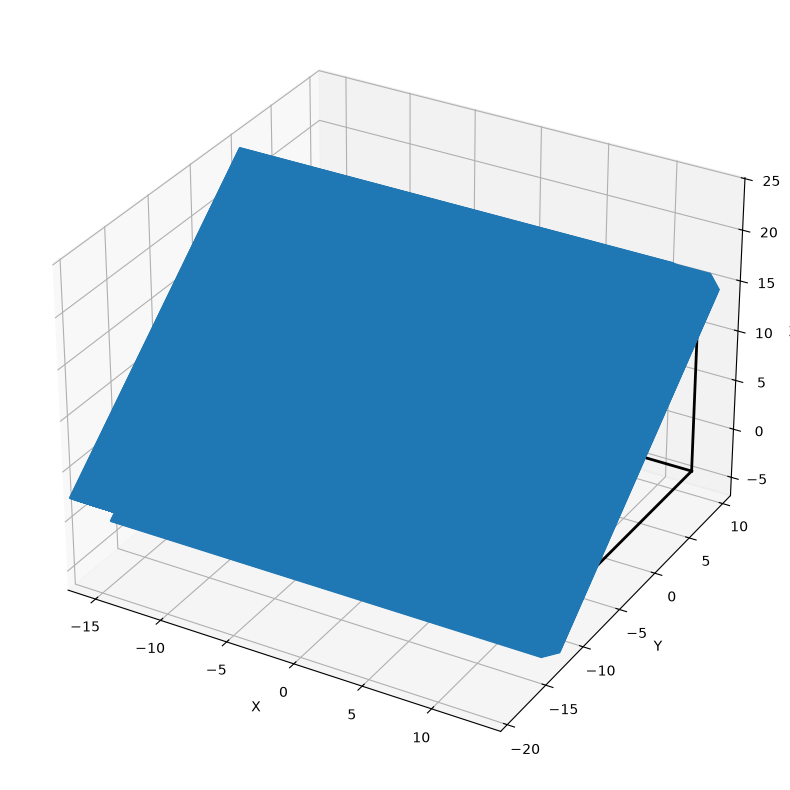

In [5]:
plot_source_rays_with_bbox(source_rays, mesh.bounds, quiver_length=10.0)


In [6]:
source_valid, source_depth, source_entry_faces = first_visible_hits(mesh, source_rays)

assert_source_ray_bundle_invariants(source_rays)
print_source_hit_summary(source_rays, source_valid, source_depth, source_entry_faces)
assert_source_hit_contract(source_rays, source_valid, source_depth, source_entry_faces)


rays: 262144
hits: 112764
hit fraction: 0.4302
entry face min/max: 199 15793


entry coverage (Stage 1 baseline): valid faces=4618
  total energy=0.430161  max energy=0.007507
  max hit_count=1968


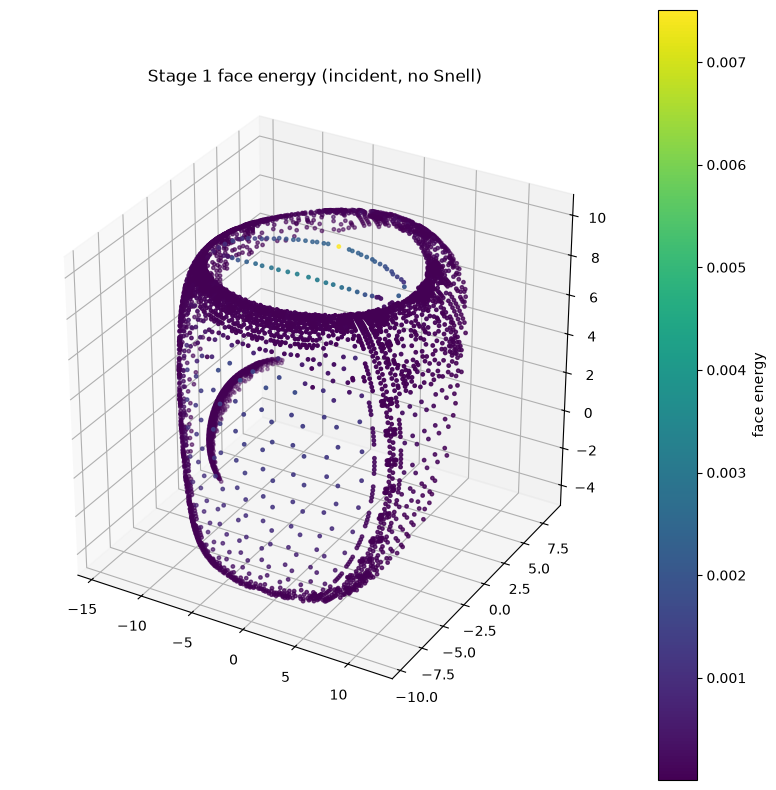

In [7]:
state = accumulate_source_coverage(mesh=mesh, source_rays=source_rays)
print_face_state_summary(state, label="entry coverage (Stage 1 baseline)")
plot_face_state_on_mesh_3d(mesh, state, title="Stage 1 face energy (incident, no Snell)")


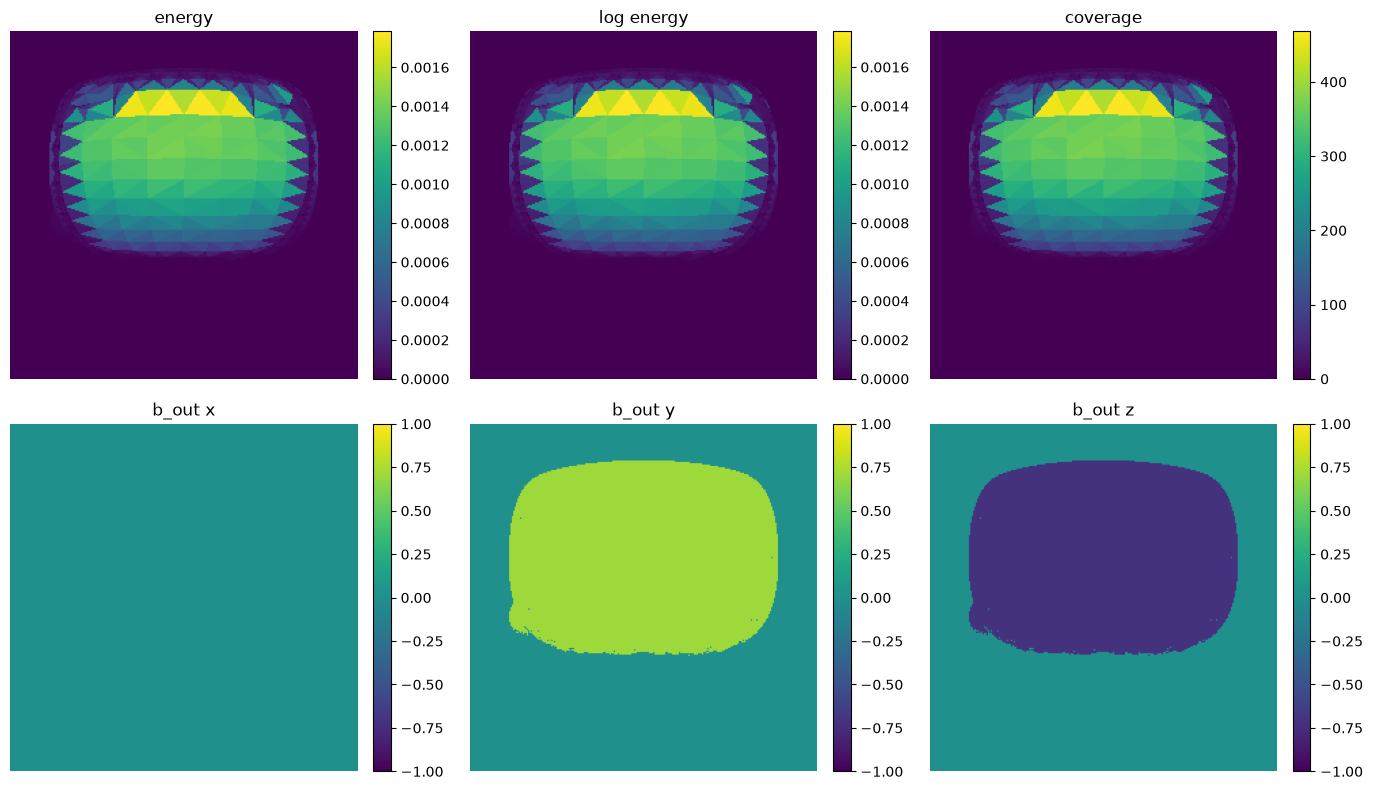

In [8]:
# Default pinhole (not auto-framed): fixed viewpoint for Stage 1 camera bridge evidence.
cam = PinholeCameraConfig()
rays = make_pinhole_rays(cam)
_valid, _depth, cam_hit_faces = first_visible_hits(mesh, rays)

images = sample_face_state_camera_images(state, cam_hit_faces, rays.sample_shape)
plot_face_state_camera_panel(images, show_raw_energy=True, show_energy_density=False)
